# W.03: The Exponential Distribution

\pagetab{W.03}

In [1]:
#! no-listings
# Import the numeric library for data handling
# and the matplotlib graphics library using
# the standard names
import matplotlib.pyplot as plot
import numpy as np
import scipy as sp
import pandas as panda
from matplotlib.ticker import (
    AutoMinorLocator,
    MultipleLocator,
)
from pandas import ExcelFile

# Import the statistics handling and plotting code
import statsmodels.graphics.gofplots as sm
import statsmodels.sandbox.distributions.extras as sm_extra

# Initialise the random number generator. This uses a seed to
# make the following script deterministic
randomiser = np.random.RandomState(1423)

In [2]:
#! no-listings
# Allow searching for file listings
import os.path

# Search for the 'fieldguide' style and 'fg_workshop' colour map. If these
# are not found, then it should default to the MatPlotLib defaults, which
# match the color sequence used in the FieldG Guides. Otherwise clear whatever
# style is in use, and use the styles as found
if os.path.isfile(
    "../../common/matplotlib/fieldguide.mplstyle"
):
    plot.style.use("default")
    plot.style.use(
        "../../common/matplotlib/fieldguide.mplstyle"
    )
if os.path.isfile(
    "../../common/matplotlib/workshops.mplstyle"
):
    plot.style.use(
        "../../common/matplotlib/workshops.mplstyle"
    )

# Define the core colour palette
signal_colours = {
    "yellow": "#f7ba0b",
    "orange": "#d4652f",
    "red": "#a02128",
    "violet": "#904684",
    "blue": "#154889",
    "green": "#317f43",
    "grey": "#9b9b9b",
    "brown": "#7b5141",
    "white": "#f4f4f4",
    "black": "#282828",
}

## Introduction

### Aim

The last of the 'general distributions' we are going to look at is the exponential distribution. The exponential distribution is related to the Poisson distribution we looked at previously in _Workshop W.02 _ (_The Poisson Distribution_). For in an exponential distribution the points within a finite probability region form a Poisson distribution. Unlike the Poisson distribution, though, the exponential distribution is continuous.

The main use for the exponential distribution lies in modelling processes in which events occur continuously and independently at a constant mean rate. Many industrial models can be built from processes created in this way, and indeed the exponential distribution is the default for industrial tools such as FlexSim [@ModellingSimulatingTechnological:2021].

### Learning Outcomes

* To understand the definition of the exponential distribution, and its relationship to the Poisson distribution
* To apply your understanding and use the exponential distribution in NumPy and SciPy to model common scenarios
* To use the NumPy masked arrays to indicate where data is missing, invalid, or incomplete for part of the known data set
* To create more complex Matplotlib charts, including those where data is missing or incomplete

## Defining the Exponential Distribution

Where a random distribution of points in an independent probability space forms a Poisson distribution, the resulting distribution is called a _Poisson point process_. The exponential distribution is then the probability distribution of the distance between events, where each event is itself modelled by a Poisson point process.

The exponential distribution is then defined in terms of the _rate parameter_ $\lambda$, as for the Poisson distribution. However the exponential distribution is _only_ defined for $\lambda \geq 0$, when the distribution follows the definitions in [@tbl:W03_ExponentialDef].

| **Term** | **Expression**                                                                                 |
|----------|------------------------------------------------------------------------------------------------|
| Mean\vspace{1.5em}     | $\mu = \dfrac{1}{\lambda}$                                                                     |
| Variance\vspace{1.5em} | $\sigma^2=\dfrac{1}{\lambda^2}$                                                                |
| PDF\vspace{1.5em}      | $f(x; \lambda) = {\begin{cases} \lambda e^{-\lambda x} & x \geq 0, \\ 0 & x < 0. \end{cases}}$ |
| CDF\vspace{1.5em}      | $F(x; \lambda)=\begin{cases} 1 - e^{-\lambda x} & x \geq 0, \\ 0 & x < 0. \end{cases}$         |

Table: Definitions of the Exponential Distribution {#tbl:W03_ExponentialDef}

The usefulness of the exponential distribution is easier to see if we rewrite the mean, $\mu$, in terms of $\lambda$

$$\lambda = \frac{1}{\mu}$$

Substituting this back into the PDF we get

$$\begin{aligned}
f(x; \mu) &= {\begin{cases} \left(\frac{1}{\mu}\right) e^{-\left(\frac{1}{\mu}\right) x} & x \geq 0, \\ 0 & x < 0. \end{cases}}\\
f(x; \mu) &= {\begin{cases} \left(\frac{1}{\mu}\right) e^{-\left(\frac{x}{\mu}\right)} & x \geq 0, \\ 0 & x < 0. \end{cases}}\\
\end{aligned}$$

From this we can see that $f(x; \mu)$ depends on one parameter: the mean,  $\mu$. Thus we can represent any _independent_ probability distribution with a constant mean interval between events using the exponential distribution. Typical examples are waiting times, mean times between failure (MTBF), or mean times to repair (MTTR)^[Note that as with the Poisson distribution, the exponential distribution **must** assume the probabilities are independent. So for the MTTR, for instance, the mean repair rate must be constant: one repair event cannot depend on the success or failure of previous event. It can only depend on an independent probability of failure.]. 

However as long as the interval is mono-dimensional (so it can be represented by $\mu$ a single value) and independent, then the exponential distribution can be used. For example, in a continuous manufacturing process $\mu$ might be the interval between defects. We could then use the exponential distribution to model  probabilities of defects occurring a specific intervals.



## Plotting the Exponential Distribution in SciPy

### Relating the Standard Distribution to `loc` and `scale`

In SciPy, the [`scipy.stats.expon`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html#scipy.stats.expon) class provides the basic interface to the exponential distribution. However, note that the core distribution provided by `scipy.stats.expon` is

$$f(x) = \exp(-x)\quad x \geq 0$$

From [@tbl:W03_ExponentialDef] we know the general PDF is given by

$$f(x; \lambda) = {\begin{cases} \lambda e^{-\lambda x} & x \geq 0, \\ 0 & x < 0. \end{cases}}$$

Thus without parameters, the SciPy `scipy.stats.expon` class is only giving the _standard exponential distribution_, where $\lambda = 1$. To obtain other versions of the exponential distribution, we muse use the mean rate ($\mu$), which is provided as the '`scale`' parameter for the `scipy.stats.expon.pdf()` and `scipy.stats.expon.cdf()` methods. 

From rearranging the PDF from [@tbl:W03_ExponentialDef], we noted using the mean rate leads to a definition of the PDF as 

$$f(x; \mu) = {\begin{cases} \left(\frac{1}{\mu}\right) e^{-\left(\frac{1}{\mu}\right) x} & x \geq 0, \\ 0 & x < 0. \end{cases}}$$

where 

$$\mu = \dfrac{1}{\lambda}$$

Consequently an arbitrary exponential distribution requires either first calculating $\mu$ as `scale = 1 / lambda`, or setting $\mu$ (`scale`) directly. Either way gives the correct `scale` for the `scipy.stats.expon.pdf()` or `scipy.stats.expon.cdf()` methods.

The `loc` parameter to the `scipy.stats.expon.pdf()` or `scipy.stats.expon.cdf()` methods, as usual, 'shifts' the peak of the exponential from the standard location. This means that for a given `y`, `y = (x - loc) / scale`. Note that as with the other distribtions, setting `loc` does not make the exponential distribution non-central. If you need a more general shape for the distribution, you will need to explore the other parts of the [`scipy.stats` library](https://docs.scipy.org/doc/scipy/reference/stats.html).

### Plotting the Standard PDF and CDF of the Exponential Distribution

Understanding the influence of `loc` and `scale` on the `scipy.stats.expon` distribution is easier with a few examples. We will start by defining a common range of $x$ values for these examples, from -5 to 10, and store these in `exp_x_values`. Since `exp_x_values` has a high density for plotting purposes, we will also define `exp_x_tick_at` to hold the $x$ axis values where we want to put the axis labels

In [3]:
exp_x_values = np.linspace(-5.0, 10.0, 100000)
exp_x_tick_at = np.arange(-5, 11, 1)

We will first display the probability density function `pdf` and the cumulative distribution function `cdf` of exponential distribution with $\lambda = 1$. To make later examples easier to follow, we will first define $\mu$ and $\lambda$ as separate variables^[Since '`lambda`' is now a reserved word for anonymous functions, we will again use '`p_lambda`' for the rate parameter $\lambda$.]

In [4]:
p_lambda = 1
mu = 1 / p_lambda

For the first curve we will plot the _standard exponential distribution_, using no parameters to the SciPy methods. Calling the `scipy.stats.expon.pdf()` methods gives [@fig:W03_ExponentialPDF1], and `scipy.stats.expon.cdf()` gives [@fig:W03_ExponentialCDF1]. The code for both of these should be familiar from earlier _Workshops_, and the shape of the two distributions matches what we would expect from the $\exp()$ function.

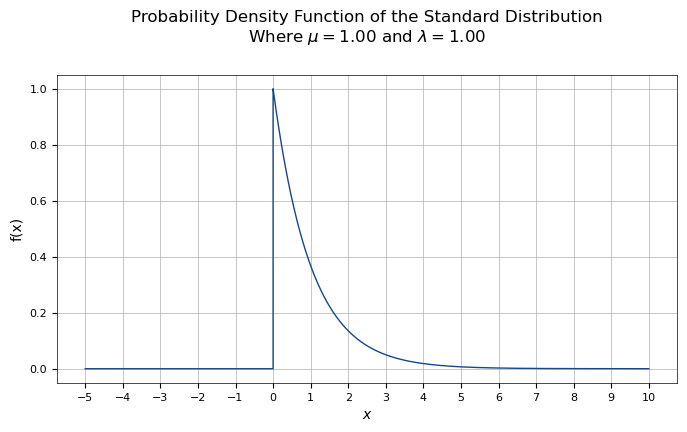

In [5]:
# A Quick Plot of the Standard Exponential PDF where $\mu = 1$
# and $\lambda = 1$ in the Real Interval $[-5.0, 10.0]$
# fig:W03_ExponentialPDF1

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")
plot.xticks(exp_x_tick_at)

# Label the axes
plot.xlabel("$x$")
plot.ylabel("f(x)")

# Label the plot
plot.title(
    "Probability Density Function of the Standard Distribution\n"
    "Where $\\mu = $"
    + f"{mu:.2f}"
    + " and $\\lambda = $"
    + f"{p_lambda:.2f}",
    pad=24.0,
)

# Display the graph
plot.plot(exp_x_values, sp.stats.expon.pdf(exp_x_values))

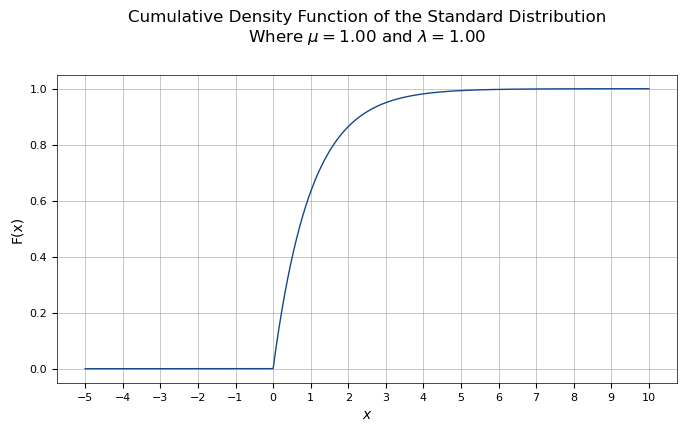

In [6]:
# The Plot of the Standard Exponential CDF where $\mu = 1$
# and $\lambda = 1$ in the Real Interval $[-5.0, 10.0]$
# fig:W03_ExponentialCDF1

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")
plot.xticks(exp_x_tick_at)

# Label the axes
plot.xlabel("$x$")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Cumulative Density Function of the Standard Distribution\n"
    "Where $\\mu = $"
    + f"{mu:.2f}"
    + " and $\\lambda = $"
    + f"{p_lambda:.2f}",
    pad=24.0,
)

# Display the graph
plot.plot(exp_x_values, sp.stats.expon.cdf(exp_x_values))

However, whilst the CDF curve in [@fig:W03_ExponentialCDF1] looks reasonable there is a problem with the PDF curve in [@fig:W03_ExponentialPDF1]. For in [@fig:W03_ExponentialPDF1] we see a sharp jump at $x = 0$, which strictly should be a _discontinuity_ (see the definition in [@tbl:W03_ExponentialDef]). Removing that discontinuity is going to take a bit more work.

There are [three basic approaches](https://matplotlib.org/stable/gallery/lines_bars_and_markers/masked_demo.html) to creating the discontinuity in Matplotlib: which also apply to any missing or incomplete data

1. Remove the data from the $x$ or $y$ values being plotted
2. Use a [_masked array_](https://numpy.org/doc/stable/reference/maskedarray.generic.html) to indicate missing or invalid entries that should not be plotted
3. Set the $x$ or $y$ data value to `NaN` ('_not a number_'), which will cause Matplotlib to skip that entry

For this problem, we will pick Option 2 and used a NumPy masked array. You can read the documentation for the [`numpy.ma`](https://numpy.org/doc/stable/reference/maskedarray.generic.html#module-numpy.ma) module for the full details of how these work. Essentially, though, they create a _mask_ using a Boolean array with the same shape as the 'data array'. By default every element in the companion mask array is `False`, indicating the corresponding element in the data array is valid. However if we set an element in the mask array to `True`, then we are indicating the element in the same position in the data array is _invalid_. 

The advantage of this technique is we don't alter the shape of the data array.  This makes it much easier to handle the data in Matplotlib, as it will detect the mask array for us and simply skip invalid values. Matplotlib won't complain about the $x$ and the $y$ arrays not being the same shape, as the data is still contained somewhere.

Most of the `numpy.ma` module is concerned with creating the companion mask array, and manipulating the elements in the mask. We are going to use the simplest approach here, which is to create the data array first, and then add the mask using [`ma.masked_where()`](https://numpy.org/doc/stable/reference/generated/numpy.ma.masked_where.html#numpy.ma.masked_where)^[If you look at the documentation, most of the `numpy.ma` module interface is syntactic sugar for the `numpy.ma.masked_where()` method. So there are other ways of doing things, but most boil down to the same basic approach.]

To create the mask for the invalid values, we need to figure out where the invalid values are. For the standard exponential PDF the value we are looking for is at $(x, y) = (0, 1)$^[If we look at [@tbl:W03_ExponentialDef], this isn't strictly correct as $\lambda e^{-\lambda x}$ **is** defined for $x = 0$. So really we should be looking for the $x$ value _infinitesimally_ close to $-0$, but not actually $0$. However we are also deliberately using a dense set of $x$ values, with several values very close to $0$. So in practice the discontinuity should be in more or less the right place, and we can simplify the search considerably.]. Using `np.ma.masked_where()`, the first parameter is the Boolean expression used to mark invalid values. We could an arbitrary expression here^[Ideally we want to find the value $(x, y) = (0, \exp(-x))$, as we can reuse this code for other distributions. But there is a slight complication we will come to shortly.]: as long as the result is a `True` or `False`. From the discussion above, we are looking for $x = 0$, so our mask becomes

In [7]:
pdf_x_values = np.ma.masked_where(
    exp_x_values == 0, exp_x_values
)

The second parameter of `np.ma.masked_where()` is the array to copy the values from. In this case the array of `x` ($x$) values created earlier. Each element copied will be tested, and the appropriate bit in the mask set to mark the discontinuity as invalid.

Once the mask is set, Matplotlib will use the masked array in just the same way as a standard array. So the code for [@fig:W03_ExponentialPDF2] is essentially the same as [@fig:W03_ExponentialPDF1], but should now result in a plot with the correct discontinuity.

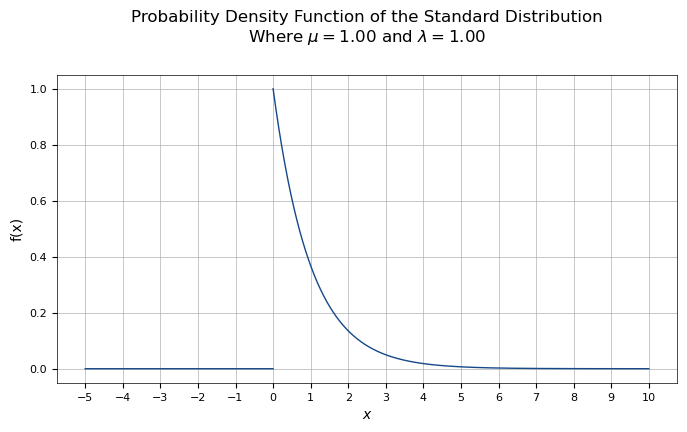

In [8]:
# A Plot of the Standard Exponential PDF where $\mu = 1$
# and $\lambda = 1$ in the Real Interval $[-5.0, 10.0]$,
# Showing the Expected Discontinuity
# fig:W03_ExponentialPDF2

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")
plot.xticks(exp_x_tick_at)

# Label the axes
plot.xlabel("$x$")
plot.ylabel("f(x)")

# Label the plot
plot.title(
    "Probability Density Function of the Standard Distribution\n"
    "Where $\\mu = $"
    + f"{mu:.2f}"
    + " and $\\lambda = $"
    + f"{p_lambda:.2f}",
    pad=24.0,
)

# Display the graph
plot.plot(pdf_x_values, sp.stats.expon.pdf(exp_x_values))

### Changing the  `loc` Parameter

With the standard curves for the PDF in [@fig:W03_ExponentialPDF2] and the CDf in [@fig:W03_ExponentialPDF1], we can now look at the `loc` and `scale` parameters. We will start with `loc` here, both as the simplest in terms of impact and because it develops the code we used for [@fig:W03_ExponentialPDF2].

For both of the following examples we will use a range of locations, defined as follows

<!-- Going to repeat the above exercise using `scale = 1/lambda` and `loc` to show the impact of the differences on the distribution pdf and cdf. As can be clearly seen the rate parameter $\lambda$ which is the inverse of `scale` changes the y-value of the first non-zero point in the distribution, whereas the `loc` parameter shifts the distribution on the x-axis so `loc=-2` means the first non-zero value of $f(x)$ occurs at $x=-2$ -->

In [9]:
# Values for the location (`loc`) of the standard PDF
locations = [-3.75, -0.5, 1, 2.25]

We would also like to still plot the discontinuities at the locations above. But there is a slight challenge. Although we have a very dense set of values for the $x$ axis we are not _guaranteed_ to have _exactly_ these `locations` in `exp_x_values` for two reasons

1. We specified the `start` and `stop` values for [`np.linspace()`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html), but not the _spacing_ between values. We can set the spacing as the second parameter (instead of '`stop`') by setting '`retstep=True`': but instead we provided a number of values to generate in the interval. This means we may not have _exactly_ the values we need in the `exp_x_values` array.
2. There is always an inherent uncertainty with floating point values in any language. Working out the precision of Python floating point values is a little tricky, but usually they are equivalent to the '`double`' precision in C and C++^[That is the CPython interpreter usually defaults to the `base64` standard of IEEE 754 (IEEE Standard for Floating-Point Arithmetic) [@IEEEStandardFloatingPoint:2019]. Other versions of Python may use a different precision for floating point numbers. And even CPython may use alternative representations depending on the underlying hardware. Read the documentation carefully, and undertake platform checks, if the hardware precision is important.]. The Python documentation has a good section on [floating point issues](https://docs.python.org/3/tutorial/floatingpoint.html).

Since this is a common problem, there are a number of standard solutions. The simplest is to use a 'range of uncertainty' around the specific value we are looking for. For example, we know the separation in `exp_x_values`, so we could search for the 'right' value within $\pm$10 of these intervals. This should get us within the interval.

One way of doing this is to use [`numpy.ma.masked_inside`](https://numpy.org/doc/stable/reference/generated/numpy.ma.masked_inside.html#numpy.ma.masked_inside), and give the upper and lower range we are looking for. We will have to do this for every value in `locations` as below

In [10]:
x_sep = 10 * (1 / 100000)

for index in range(4):
    pdf_x_values = np.ma.masked_inside(
        exp_x_values,
        locations[index] - x_sep,
        locations[index] + x_sep,
    )

Since uncertainty in floating point values is so common, Python does provide a helper function to make finding numbers within a tolerance interval slightly easier. In the Python standard `math` library, the [`math.isclose()`](https://docs.python.org/3/library/math.html#math.isclose) function returns `True` if two values are within specified tolerances. And NumPy has a similar function to `isclose()` for comparing whole arrays in the [`numpy.isclose()`](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html#numpy.isclose) method.

What we really want to do, though, is apply `isclose()` to each value _within_ the array: as we did for the `masked_inside()` method. NumPy provides the [`ma.masked_values()`](https://numpy.org/doc/stable/reference/generated/numpy.ma.masked_values.html#numpy.ma.masked_values) method to do this. This essentially 'automates' the provision of lower and upper limits by providing both a _relative tolerance_, '`rtol`', and _absolute tolerance_, '`atol`' to search. Conceptually the `numpy.ma.masked_values()` method then applies `isclose()` to each comparison. This should then give us what we need.

Modifying the previous code, we want an absolute uncertainty around our `locations`. So we can use the `numpy.ma.masked_values()` method as follows

In [11]:
for index in range(4):

    pdf_x_values = np.ma.masked_values(
        exp_x_values,
        locations[index],
        atol=x_sep,
    )

Using the above, we can now plot the four PDFs for the values in `location` as shown in [@fig:W03_ExponentialPDF3]. This uses the same technique we used for _Workshop W.02_ (_The Poisson Distribution_) for plotting multiple curves on a single plot^[If you want to see the impact of calling `numpy.ma.masked_values()`, try removing (or commenting out) `Line 9` to `Line 13` and re-running the cell. You will, though, also need to patch the call to `sp.stats.expon.pdf()` to use the right range of $x$ values.].

Text(0.02, 0.5, 'f(x)')

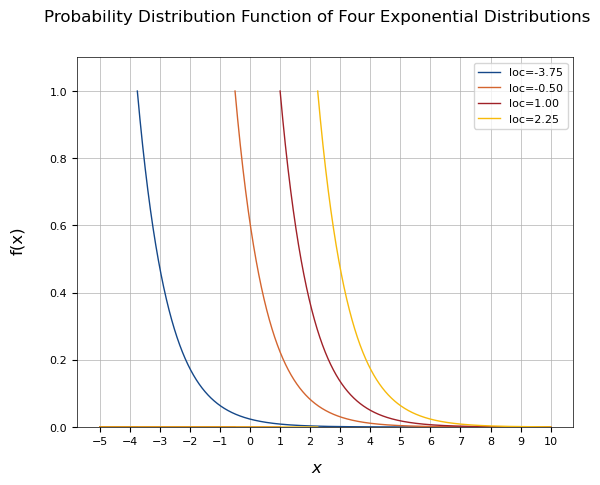

In [12]:
# Plot of the PDF Values of the Locations for Four
# Standard Exponential Distributions
# fig:W03_ExponentialPDF3

figure, subfig = plot.subplots(1, 1)

for index in range(4):

    pdf_x_values = np.ma.masked_values(
        exp_x_values,
        locations[index],
        atol=x_sep,
    )

    subfig.plot(
        pdf_x_values,
        sp.stats.expon.pdf(
            exp_x_values, loc=locations[index]
        ),
        "-",
        label=f"loc={locations[index]:.2f}",
    )

# Format the plot
subfig.grid(True, which="both")
subfig.set_xticks(exp_x_tick_at)

subfig.legend(loc="best")


# Set the axis limits
subfig.set_ylim(0, 1.1)

# Label the plot
figure.suptitle(
    "Probability Distribution Function of Four Exponential "
    "Distributions\n",
)

# Label the axes
figure.supxlabel("$x$")
figure.supylabel("f(x)")

We don't have to adjust the CDF curves for discontinuity, so the code for [@fig:W03_ExponentialCDF2] is a little simpler

Text(0.02, 0.5, 'F(x)')

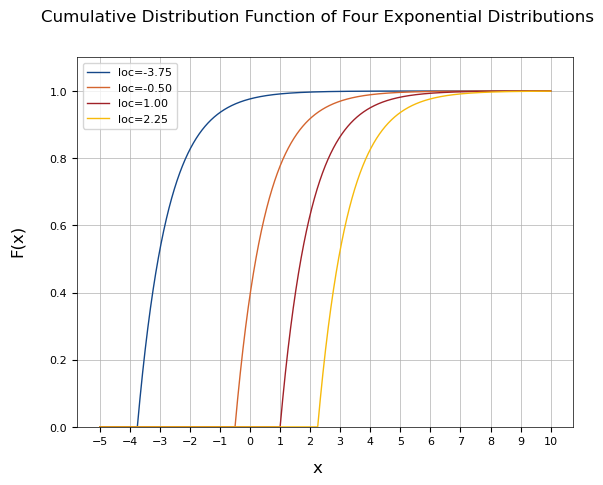

In [13]:
# Plot of the CDF Values of the Locations for Four
# Standard Exponential Distributions
# fig:W03_ExponentialCDF2

figure, subfig = plot.subplots(1, 1)

for index in range(4):

    subfig.plot(
        exp_x_values,
        sp.stats.expon.cdf(
            exp_x_values, loc=locations[index]
        ),
        "-",
        label=f"loc={locations[index]:.2f}",
    )

# Format the plot
subfig.grid(True, which="both")
subfig.set_xticks(exp_x_tick_at)

subfig.legend(loc="best")


# Set the axis limits
subfig.set_ylim(0, 1.1)

# Label the plot
figure.suptitle(
    "Cumulative Distribution Function of Four Exponential "
    "Distributions\n",
)

# Label the axes
figure.supxlabel("x")
figure.supylabel("F(x)")

What we can see from [@fig:W03_ExponentialPDF3] and [@fig:W03_ExponentialCDF2] is that the overall _shape_ of the curves for the PDF and CDF are identical to [@fig:W03_ExponentialPDF2] and [@fig:W03_ExponentialCDF1]. The only difference is that `loc` 'shifts' the curve to start at a location other than $0$ (which the standard curves always start from). That is $y = f(x) + \operatorname{loc}$ or $y = F(X) + \operatorname{loc}$.

### Changing the `scale` Parameter

To see the impact of the '`scale`' parameter of `expon.pdf()` and `expon.cdf()`, we will revert to the standard curve used in [@fig:W03_ExponentialPDF2] and [@fig:W03_ExponentialCDF1]. This time we will pick four scale values as follows

In [14]:
scales = [0.25, 0.5, 1, 1.5]

The code for the PDF in [@fig:W03_ExponentialPDF4] and the CDF in [@fig:W03_ExponentialCDF3] is then shown below. Note the use of the masked array in `Line 5` to `Line 7` to remove the discontinuities in [@fig:W03_ExponentialPDF4].

Text(0.02, 0.5, 'f(x)')

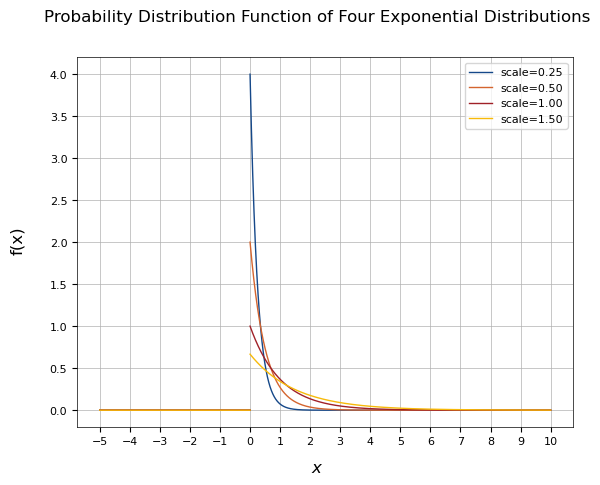

In [15]:
# Plot of the PDF Values of Different Scales for Four
# Standard Exponential Distributions
# fig:W03_ExponentialPDF4

pdf_x_values = np.ma.masked_where(
    exp_x_values == 0, exp_x_values
)

figure, subfig = plot.subplots(1, 1)

for index in range(4):

    subfig.plot(
        pdf_x_values,
        sp.stats.expon.pdf(
            exp_x_values, scale=scales[index]
        ),
        "-",
        label=f"scale={scales[index]:.2f}",
    )

# Format the plot
subfig.grid(True, which="both")
subfig.set_xticks(exp_x_tick_at)

subfig.legend(loc="best")

# Label the plot
figure.suptitle(
    "Probability Distribution Function of Four Exponential "
    "Distributions\n",
)

# Label the axes
figure.supxlabel("$x$")
figure.supylabel("f(x)")

Text(0.02, 0.5, 'F(x)')

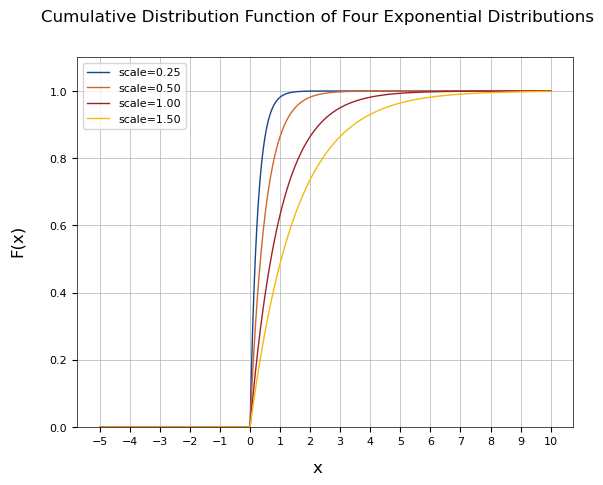

In [16]:
# Plot of the CDF Values of Different Scales for Four
# Standard Exponential Distributions
# fig:W03_ExponentialCDF3

figure, subfig = plot.subplots(1, 1)

for index in range(4):

    subfig.plot(
        exp_x_values,
        sp.stats.expon.cdf(
            exp_x_values, scale=scales[index]
        ),
        "-",
        label=f"scale={scales[index]:.2f}",
    )

# Format the plot
subfig.grid(True, which="both")
subfig.set_xticks(exp_x_tick_at)

subfig.legend(loc="best")


# Set the axis limits
subfig.set_ylim(0, 1.1)

# Label the plot
figure.suptitle(
    "Cumulative Distribution Function of Four Exponential "
    "Distributions\n",
)

# Label the axes
figure.supxlabel("x")
figure.supylabel("F(x)")

To discuss in more detail the patterns seen in [@fig:W03_ExponentialPDF4] and [@fig:W03_ExponentialCDF3], we will also compute the mean and variance for each distribution

In [17]:
for index in range(4):

    mean, var = sp.stats.expon.stats(
        scale=scales[index], moments="mv"
    )

    print(
        f"Exponential Distribution {index}:\t"
        f"Mean: {mean: .2f}"
        f"\tVariance: {var:.2f}"
    )

Exponential Distribution 0:	Mean:  0.25	Variance: 0.06
Exponential Distribution 1:	Mean:  0.50	Variance: 0.25
Exponential Distribution 2:	Mean:  1.00	Variance: 1.00
Exponential Distribution 3:	Mean:  1.50	Variance: 2.25


From the above we should be able to see that the '`scale`' value for the `scipy.expon` distribution is the same as the _mean_. We known from [@tbl:W03_ExponentialDef] that the mean, $\mu$, is defined as

$$\mu = \frac{1}{\lambda}$$

hence

$$\lambda = \frac{1}{\mu}$$

And we can see this in [@fig:W03_ExponentialPDF4], as the starting point for each PDF is at $\lambda$ on the $y$ axis (and '`loc = 0`' on the $x$ axis). 

Similarly the variance is defined in [@tbl:W03_ExponentialDef] as

$$\sigma^2=\dfrac{1}{\lambda^2}$$

Knowing that `scale` is the mean, we would therefore expect to see 

In [18]:
for index in range(4):

    mean = scales[index]
    p_lambda = 1 / mean
    var = 1 / (pow(p_lambda, 2))

    print(
        f"Distribution {index}:\t"
        f"\tLambda: {p_lambda: .2f}"
        f"\tMean: {mean: .2f}"
        f"\tVariance: {var:.2f}"
    )

Distribution 0:		Lambda:  4.00	Mean:  0.25	Variance: 0.06
Distribution 1:		Lambda:  2.00	Mean:  0.50	Variance: 0.25
Distribution 2:		Lambda:  1.00	Mean:  1.00	Variance: 1.00
Distribution 3:		Lambda:  0.67	Mean:  1.50	Variance: 2.25


You can check the curves in [@fig:W03_ExponentialPDF4] and [@fig:W03_ExponentialCDF3] match these expectations. Note especially the impact of the variance on the CDF curves in [@fig:W03_ExponentialCDF3], and what the variance tells us about the shape of these curves.

### Extra Mile: Changing both `loc` and `scale`

Given the discussion above, you should be able to sketch the PDF and CDF curves for the distributions given by the code below

In [19]:
locations = [0, 0, 0, 0.5, -2]
scales = [0.5, 1, 1.5, 1, 1.5]

for index in range(5):
    mean = scales[index]
    p_lambda = 1 / mean
    var = 1 / (pow(p_lambda, 2))

    print(
        f"Distribution {index+1}\t"
        f"Location: {locations[index]: 2.2f}\t"
        f"Mean: {mean: 2.2f}\t"
        f"Variance: {var: 2.2f}"
    )

Distribution 1	Location:  0.00	Mean:  0.50	Variance:  0.25
Distribution 2	Location:  0.00	Mean:  1.00	Variance:  1.00
Distribution 3	Location:  0.00	Mean:  1.50	Variance:  2.25
Distribution 4	Location:  0.50	Mean:  1.00	Variance:  1.00
Distribution 5	Location: -2.00	Mean:  1.50	Variance:  2.25


After sketching the curves, draw the PDF and CDF curves using Matplotlib and check the shape of the calculated curves against your sketches.

To fully explore the relationship between '`loc`' and '`shape`', you might also want to create an interactive plot. You can also modify the code above to include other features from [@tbl:W03_ExponentialDef] that make it easier to sketch the plot.

## Using the Exponential Distribution

### Point Probabilities and Probability Ranges

Like the Poisson distribution, once you understand the influence of $\lambda$ on the shape of the distribution, the graphs of PDF and CDF are somewhat less useful in solving problems. Instead, like the Poisson distribution, we use the exponential PDF to estimate specific probabilities (point probabilities) and the CDF to estimate ranges. In practice, though, we rarely use the exponential PDF for two reasons

1. The probability estimate at a 'point' is also a Poisson distribution, since (from the definition) we assume the distribution at this point follows a Poisson point process.
2. The main use for the exponential distribution is to model mono-dimensional intervals between the individual Poisson distributed 'points' in the probability space. If we are not interested in the intervals _between_ these points, the Poisson distribution is the better model as we want to investigate this region of probability. But we know this region forms a Poisson distribution: and if it doesn't the basic exponential distribution isn't going to help anyway.

### Modelling Interval Estimates

In use, then, the exponential distribution is much like the earlier use of the Poisson distribution we looked at in _Workshop W.02_ (_The Poisson Distribution_). By far the most common mono-dimensional used is _time_, and this is the interval we will use in the examples below; starting with

>The interval $X$ seconds between cars passing a point on a motorway is given by an exponential distribution with $\lambda = 2$. What is the probability (to 5 d.p.) that:
>
>    a. The interval to the next car is less than $1.5$ s --- given by $P(X \leq 1.5)$  
>    b. The interval to the next car is longer than $3$ s --- given by $P(X > 3)$  
>    c. The interval to the next car is between $1$ s and $2$ s --- given by $P(1 \leq X \leq 2)$  

We have been given $\lambda$, and we know that the SciPy '`scale`' parameter for both the PDF and CDF is `scale = 1 / lambda`. So we can calculate that first 

In [20]:
scale = 1 / 2

All of the other features we have been asked to find are probability ranges, so we will be using the CDF. Setting the `scale` parameter for each curve, we can calculate $P(X)$ for the specific probabilities as

In [21]:
part_a = expon.cdf(1.5, scale=scale)
part_b = 1 - expon.cdf(3, scale=scale)
part_c = expon.cdf(2, scale=scale) - expon.cdf(
    1, scale=scale
)

print(
    f"P(X < 1.5)\t = {part_a: .5f}\n"
    f"P(X > 3)\t = {part_b: .5f}\n"
    f"P(1 ≤ X ≤ 2)\t = {part_c: .5f}\n"
)

NameError: name 'expon' is not defined

Note that as for the Poisson estimates, the CDF naturally gives a probability estimate $\leq$ a specific interval. So for (b) we need to calculate $1 - P(X)$ to estimate the probability _above_ the required interval.

Also note the order of the calculations for (c): we need to calculate $P(X \leq 2)$ _first, then subtract $P(1 \leq X)$ to find the correct interval. 

Both of these notes also apply the the second example problem

> In a production process a monitor will issue a warning signal when an action is required. The interval, $X$ hours, between successive signals follows an exponential distribution with $\lambda = 0.08$. What is the probability (to 4 d.p.) that the interval between 2 signals is:
>
>    a. Less than 2 hours?  
>    b. More than 50 hours?  
>    c. Between 10 and 20 hours?   

In [ ]:
scale = 1 / 0.08

part_a = expon.cdf(2, scale=scale)
part_b = 1 - expon.cdf(50, scale=scale)
part_c = expon.cdf(20, scale=scale) - expon.cdf(
    10, scale=scale
)

print(
    f"P(X < 2)\t = {part_a: .4f}\n"
    f"P(X > 50)\t = {part_b: .4f}\n"
    f"P(10 ≤ X ≤ 20)\t = {part_c: .4f}\n"
)

P(X < 2)	 =  0.1479
P(X > 50)	 =  0.0183
P(10 ≤ X ≤ 20)	 =  0.2474






## Questions

Use Python to answer the following questions. Where appropriate give answers to 4 decimal places.




1.  The lifetime of a light bulb is $X$ hours, where $X$ can be modelled by an exponential distribution with parameter $\lambda = 0.0125$.

    a. What is the mean and variance of the lifetime of a light bulb?  
    b. What is the probability that the lifetime of a bulb is less than 100 hours?  
    c. What is the probability that the lifetime of a bulb more than 200 hours?  
    d. What is the probability that the lifetime of a bulb between 50 and 150 hours?  


*Answer*:

In [ ]:
# code for question 1(a) -- 1(d)

2. The lifetime $H$ in hours of an electrical component is modelled by an exponential distribution with a parameter $\lambda = 0.001$:

    a. What is the mean and variance of the lifetime of a component?  
    b. What is the probability that the lifetime of a randomly selected component is less than 1200 hours?  
    c. What is the probability that the lifetime of a randomly selected component is more than 1500 hours?  
    d. What is the probability that of a randomly selected component is between 1000 and 2000 hours?   


*Answer:*

In [ ]:
# code for question 2(a) -- 2(d)

3. The packet inter-arrival time $T$ seconds in a system is modelled using an exponential distribution with a parameter $\lambda = 0.4$. 

    a. What is the mean and variance of the packet inter-arrival time?  
    b. What is the probability that inter-arrival time will be less than 2s?  
    c. What is the probability that the inter-arrival time will be greater than 1.5s?  
    d. What is the probability $T$ will be between 1 and 4s?  

In [ ]:
# code for question 3(a) -- 3(d)

## References